In [1]:
import os
import pandas as pd
import csv
import matplotlib.pyplot as plt
from scipy.stats import spearmanr


In [2]:
# Get the directory with the notebooks, including its subdirectories
current_dir = os.getcwd()

# Get the directories with data and results
data_dir = os.path.join(current_dir, "data")
temporary_dir= os.path.join(current_dir, "temporary_data")
results_dir = os.path.join(current_dir, "results")

project_dir = os.path.dirname(current_dir)

inputs_dir = os.path.join(project_dir, "inputs")



In [3]:
# After we need to put together the PSYS and Size values for each of the 3 different implementations

# Example usage
csv_with_ec = os.path.join(results_dir, 'averagePSYS_all_repeats.csv')
# Read the first CSV file
df = pd.read_csv(csv_with_ec, delimiter=';')
df


,Program,Utilities,PSYS
0,base64,BusyBox,4.303545e+05
1,base64,GNU,3.495048e+05
2,base64,ToyBox,9.077979e+05
3,basename,BusyBox,2.937127e+05
4,basename,GNU,2.940271e+05
...,...,...,...
79,true,GNU,2.947838e+05
80,true,ToyBox,2.908623e+05
81,wc,BusyBox,8.755721e+07
82,wc,GNU,4.546934e+08


In [4]:
# Note: The two following tables are in fact the used data 
# for Table 1 in the paper

df_pivot = df.pivot(index='Program', columns='Utilities')
df_pivot

PSYS                            
Utilities       BusyBox           GNU        ToyBox
Program                                            
base64     4.303545e+05  3.495048e+05  9.077979e+05
basename   2.937127e+05  2.940271e+05  2.926171e+05
cat        3.755542e+07  2.125736e+06  1.517433e+09
chmod      1.951976e+06  1.539669e+06  1.523403e+06
cksum      2.458047e+08  1.139345e+07  2.062460e+08
comm       1.208715e+08  5.506528e+07  3.383169e+08
cp         1.112494e+08  1.088484e+08  1.474435e+08
cut        4.932394e+06  2.207312e+06  1.139999e+07
date       3.122152e+05  3.153679e+05  3.153069e+05
dirname    3.100884e+05  3.215384e+05  3.122429e+05
du         4.905932e+05  5.232377e+05  5.185350e+05
echo       3.052972e+05  3.214469e+05  3.108848e+05
expand     1.456601e+07  7.273004e+06  5.023578e+05
factor     3.162590e+05  3.219719e+05  3.161642e+05
false      3.053183e+05  3.201407e+05  3.147483e+05
head       3.079398e+05  3.200187e+05  3.148215e+05
id         3.081933e+05  3.279167e+05  3.132042e+05
link       3.063437e+05  3.172843e+05  3.123558e+05
ln         3.051200e+05  3.224753e+05  3.357046e+05
logname    3.100822e+05  3.223869e+05  3.108298e+05
ls         8.980628e+05  1.048413e+06  3.487467e+06
md5sum     1.431506e+08  1.185998e+08  2.640305e+08
mkdir      2.976526e+05  3.066123e+05  3.003350e+05
mv         2.952782e+05  3.069390e+05  2.968988e+05
sort       3.182993e+08  9.554343e+07  4.693342e+08
touch      2.945090e+05  2.951958e+05  2.951806e+05
true       2.948539e+05  2.947838e+05  2.908623e+05
wc         8.755721e+07  4.546934e+08  1.514813e+08

In [5]:
# These are the DIFF.% values in Table 1 in the paper

df_pivot['Difference_BusyBox'] = ((df_pivot['PSYS']['BusyBox'] - df_pivot['PSYS']['GNU']) / df_pivot['PSYS']['GNU']) * 100
df_pivot['Difference_ToyBox'] = ((df_pivot['PSYS']['ToyBox'] - df_pivot['PSYS']['GNU']) / df_pivot['PSYS']['GNU']) * 100
new_df = pd.DataFrame({
                       'BusyBox': df_pivot['Difference_BusyBox'].round(2),
                       'ToyBox': df_pivot['Difference_ToyBox'].round(2)})
new_df

,BusyBox,ToyBox
Program,,
base64,23.13,159.74
basename,-0.11,-0.48
cat,1666.70,71283.90
chmod,26.78,-1.06
cksum,2057.42,1710.22
comm,119.51,514.39
cp,2.21,35.46
cut,123.46,416.46
date,-1.00,-0.02


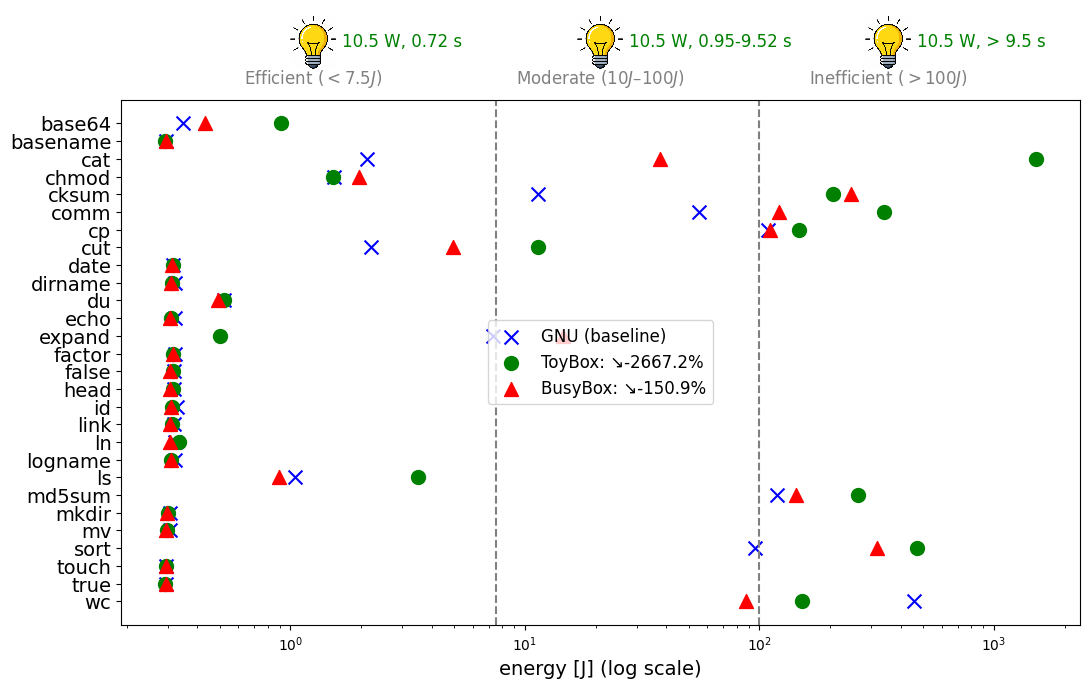

In [6]:
# Dot-plot of per-program energy (log scale) with mean-reduction legends
import os
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# Load icon
bulb_img = plt.imread(os.path.join(current_dir, 'bulb.png'))

# Extract energy for each implementation
bb = df_pivot['PSYS']['BusyBox']
gnu = df_pivot['PSYS']['GNU']
tb  = df_pivot['PSYS']['ToyBox']

# Program order as original (invert_yaxis() will flip display)
programs = df_pivot.index

# Compute mean energy reductions vs GNU
toy_energy_red = (gnu - tb) / gnu * 100
bb_energy_red  = (gnu - bb) / gnu * 100
mean_toy_energy = toy_energy_red.mean()
mean_bb_energy  = bb_energy_red.mean()

# convert microjoules to joules for plotting
gnu_j = gnu / 1e6
tb_j  = tb  / 1e6
bb_j  = bb  / 1e6

fig, ax = plt.subplots(figsize=(11, 7))

# Plot data points
ax.scatter(gnu_j, programs, marker='x', color='blue',  s=100, label='GNU (baseline)')
ax.scatter(tb_j,  programs, marker='o', color='green', s=100, label=f'ToyBox: ↘{mean_toy_energy:.1f}%')
ax.scatter(bb_j,  programs, marker='^', color='red',   s=100, label=f'BusyBox: ↘{mean_bb_energy:.1f}%')

ax.set_xscale('log')

# vertical region lines
ax.axvline(7.5, color='gray', linestyle='--')
ax.axvline(100, color='gray', linestyle='--')

# place icons, keep labels at 1.02 and timing at 1.05
regions = [
    (0.2, 'Efficient ($< 7.5 J$)', '10.5 W, 0.72 s'),
    (0.5, 'Moderate ($10 J – 100 J$)', '10.5 W, 0.95-9.52 s'),
    (0.8, 'Inefficient ($> 100 J$)', '10.5 W, > 9.5 s')
]
for x, label, timing in regions:
    ab = AnnotationBbox(OffsetImage(bulb_img, zoom=0.05),
                       (x, 1.11), xycoords='axes fraction', frameon=False)
    ax.add_artist(ab)
    ax.text(x,       1.02, label,
            transform=ax.transAxes, ha='center', va='bottom',
            fontsize=12, color='gray')
    ax.text(x + 0.03, 1.11, timing,
            transform=ax.transAxes, ha='left', va='center',
            fontsize=12, color='green')

# Flip the y-axis so programs and points reverse order
ax.invert_yaxis()

# use LaTeX mu for micro-symbol in xlabel
ax.set_xlabel(r'energy [J] (log scale)', fontsize=14)
ax.legend(loc='center', bbox_to_anchor=(0.5, 0.5), fontsize=12)
ax.tick_params(axis='y', labelsize=14)
plt.tight_layout()
plt.show()

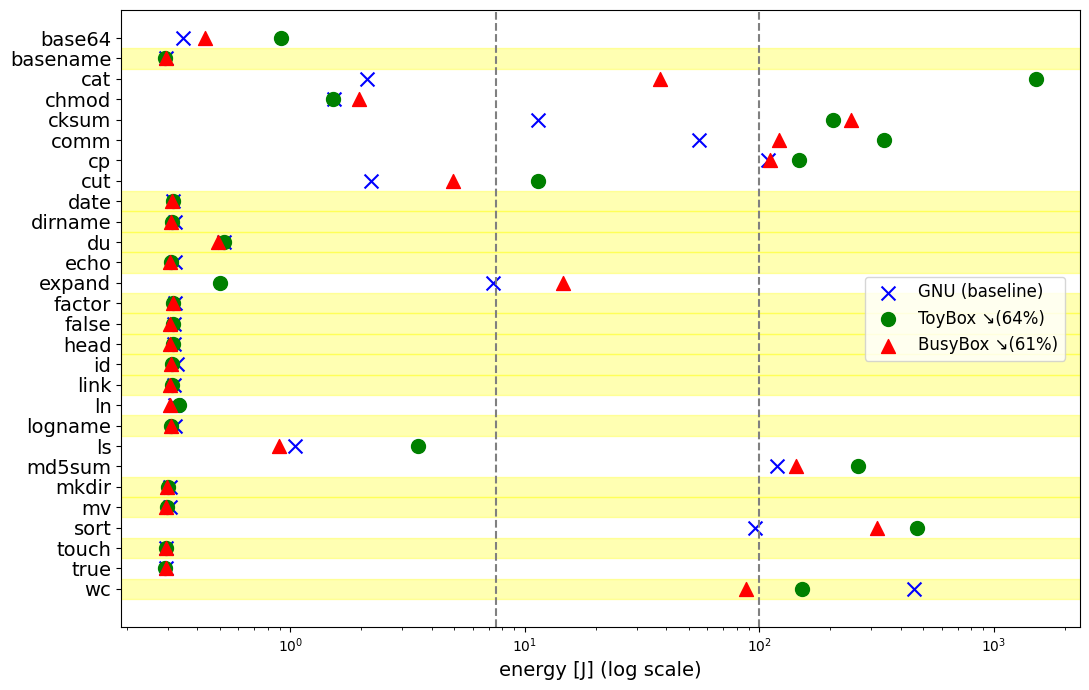

In [7]:
# Dot-plot of per-program energy (log scale) with mean-reduction legends
import os
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# Extract energy for each implementation
bb = df_pivot['PSYS']['BusyBox']
gnu = df_pivot['PSYS']['GNU']
tb  = df_pivot['PSYS']['ToyBox']

# Program order as original (invert_yaxis() will flip display)
programs = df_pivot.index

# Compute mean energy reductions vs GNU
toy_energy_red = (gnu - tb) / gnu * 100
bb_energy_red  = (gnu - bb) / gnu * 100
mean_toy_energy = toy_energy_red.mean()
mean_bb_energy  = bb_energy_red.mean()

# convert microjoules to joules for plotting
gnu_j = gnu / 1e6
tb_j  = tb  / 1e6
bb_j  = bb  / 1e6

fig, ax = plt.subplots(figsize=(11, 7))

# Plot data points
ax.scatter(gnu_j, programs, marker='x', color='blue',  s=100, label='GNU (baseline)')
ax.scatter(tb_j,  programs, marker='o', color='green', s=100, label='ToyBox ↘(64%)')
ax.scatter(bb_j,  programs, marker='^', color='red',   s=100, label='BusyBox ↘(61%)')

# highlight programs where ToyBox and BusyBox energy is lower than GNU
mask_small = (toy_energy_red > 0) & (bb_energy_red > 0)
for name in programs[mask_small]:
    y = programs.tolist().index(name)
    ax.axhspan(y - 0.5, y + 0.5, color='yellow', alpha=0.3, zorder=0)

ax.set_xscale('log')

# vertical region lines
ax.axvline(7.5, color='gray', linestyle='--')
ax.axvline(100, color='gray', linestyle='--')

# Highlight 'expand', 'ls', and 'wc' rows with green
#positions = [programs.tolist().index('expand'), programs.tolist().index('ls'), programs.tolist().index('wc')]
#for y in positions:
#    ax.axhspan(y - 0.5, y + 0.5, color="#89F77E", alpha=0.3, zorder=0)

# Highlight 'basename', 'chmod', 'cat', 'cp', 'md5sum' rows
#positions = [programs.tolist().index('basename'), programs.tolist().index('chmod'), programs.tolist().index('cat'), programs.tolist().index('cp'), programs.tolist().index('md5sum')]
#for y in positions:
#    ax.axhspan(y - 0.5, y + 0.5, color="#FAEB61", alpha=0.3, zorder=0)

# Flip the y-axis so programs and points reverse order
ax.invert_yaxis()

# use LaTeX mu for micro-symbol in xlabel
ax.set_xlabel(r'energy [J] (log scale)', fontsize=14)
ax.legend(loc='center', bbox_to_anchor=(0.88, 0.5), fontsize=12)
ax.tick_params(axis='y', labelsize=14)
plt.tight_layout()
plt.show()

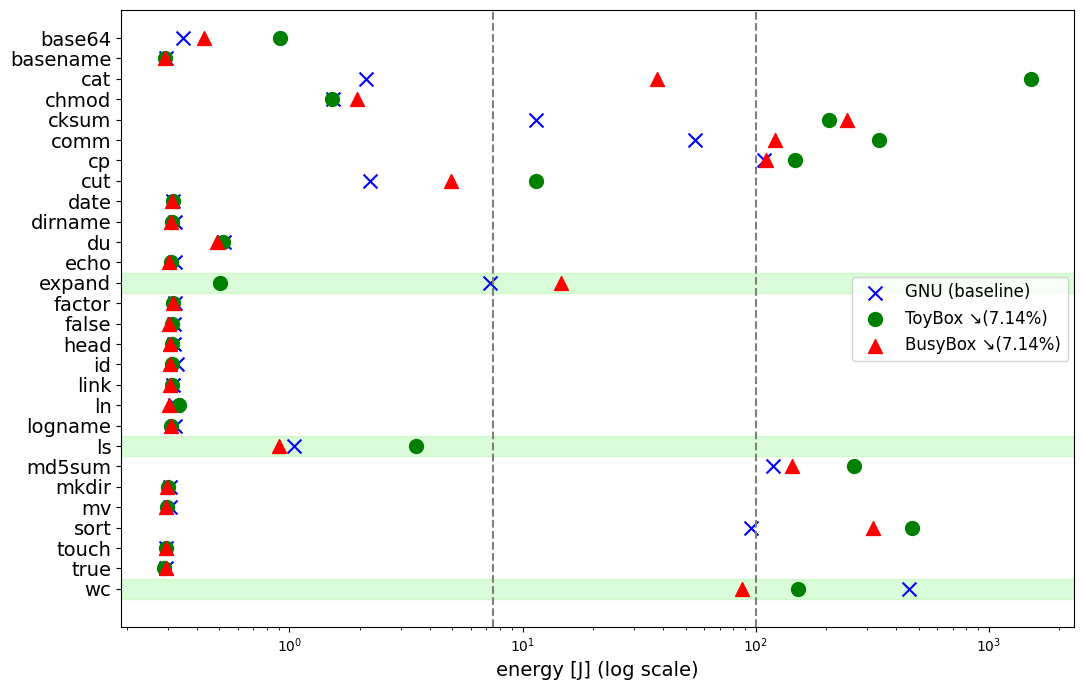

In [8]:
# Dot-plot of per-program energy (log scale) with mean-reduction legends
import os
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# Extract energy for each implementation
bb = df_pivot['PSYS']['BusyBox']
gnu = df_pivot['PSYS']['GNU']
tb  = df_pivot['PSYS']['ToyBox']

# Program order as original (invert_yaxis() will flip display)
programs = df_pivot.index

# Compute mean energy reductions vs GNU
toy_energy_red = (gnu - tb) / gnu * 100
bb_energy_red  = (gnu - bb) / gnu * 100
mean_toy_energy = toy_energy_red.mean()
mean_bb_energy  = bb_energy_red.mean()

# convert microjoules to joules for plotting
gnu_j = gnu / 1e6
tb_j  = tb  / 1e6
bb_j  = bb  / 1e6

fig, ax = plt.subplots(figsize=(11, 7))

# Plot data points
ax.scatter(gnu_j, programs, marker='x', color='blue',  s=100, label='GNU (baseline)')
ax.scatter(tb_j,  programs, marker='o', color='green', s=100, label='ToyBox ↘(7.14%)')
ax.scatter(bb_j,  programs, marker='^', color='red',   s=100, label='BusyBox ↘(7.14%)')

ax.set_xscale('log')

# vertical region lines
ax.axvline(7.5, color='gray', linestyle='--')
ax.axvline(100, color='gray', linestyle='--')

# Highlight 'expand', 'ls', and 'wc' rows with green
positions = [programs.tolist().index('expand'), programs.tolist().index('ls'), programs.tolist().index('wc')]
for y in positions:
    ax.axhspan(y - 0.5, y + 0.5, color="#89F77E", alpha=0.3, zorder=0)

# Highlight 'basename', 'chmod', 'cat', 'cp', 'md5sum' rows
#positions = [programs.tolist().index('basename'), programs.tolist().index('chmod'), programs.tolist().index('cat'), programs.tolist().index('cp'), programs.tolist().index('md5sum')]
#for y in positions:
#    ax.axhspan(y - 0.5, y + 0.5, color="#FAEB61", alpha=0.3, zorder=0)

# Flip the y-axis so programs and points reverse order
ax.invert_yaxis()

# use LaTeX mu for micro-symbol in xlabel
ax.set_xlabel(r'energy [J] (log scale)', fontsize=14)
ax.legend(loc='center', bbox_to_anchor=(0.88, 0.5), fontsize=12)
ax.tick_params(axis='y', labelsize=14)
plt.tight_layout()
plt.show()

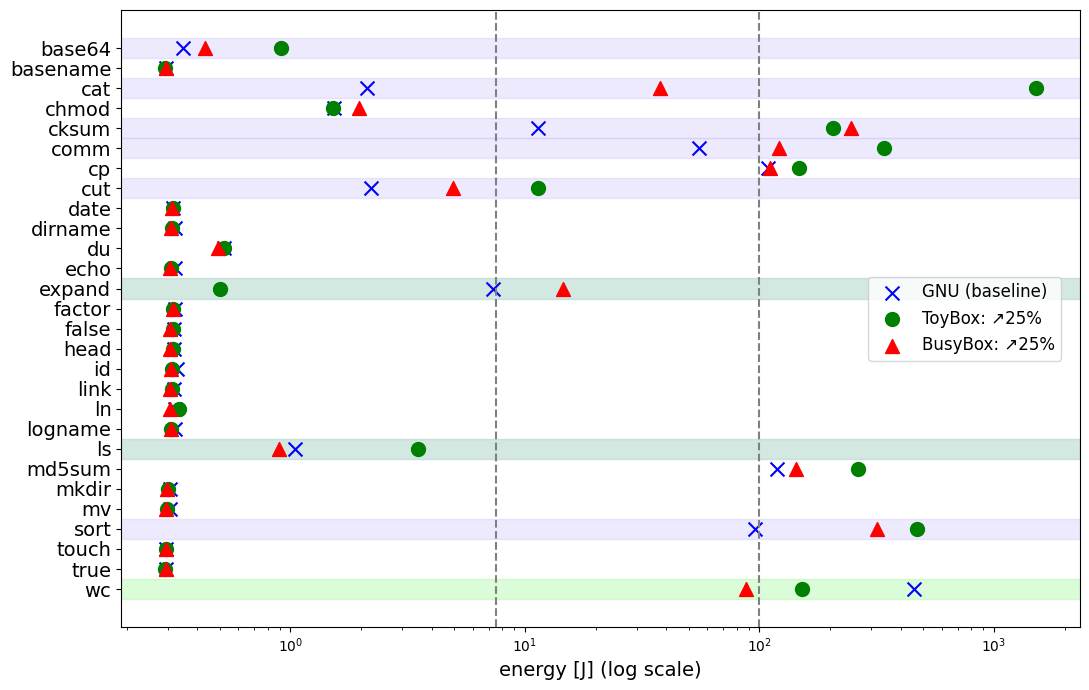

In [51]:
# Dot-plot of per-program energy (log scale) with mean-reduction legends
import os
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# Extract energy for each implementation
bb = df_pivot['PSYS']['BusyBox']
gnu = df_pivot['PSYS']['GNU']
tb  = df_pivot['PSYS']['ToyBox']

# Program order as original (invert_yaxis() will flip display)
programs = df_pivot.index

# Compute mean energy reductions vs GNU
toy_energy_red = (gnu - tb) / gnu * 100
bb_energy_red  = (gnu - bb) / gnu * 100
mean_toy_energy = toy_energy_red.mean()
mean_bb_energy  = bb_energy_red.mean()

# convert microjoules to joules for plotting
gnu_j = gnu / 1e6
tb_j  = tb  / 1e6
bb_j  = bb  / 1e6

fig, ax = plt.subplots(figsize=(11, 7))

# Plot data points
ax.scatter(gnu_j, programs, marker='x', color='blue',  s=100, label='GNU (baseline)')
ax.scatter(tb_j,  programs, marker='o', color='green', s=100, label=f'ToyBox: ↗25%')
ax.scatter(bb_j,  programs, marker='^', color='red',   s=100, label=f'BusyBox: ↗25%')

ax.set_xscale('log')

# vertical region lines
ax.axvline(7.5, color='gray', linestyle='--')
ax.axvline(100, color='gray', linestyle='--')

# Highlight 'expand', 'ls', and 'wc' rows
positions = [programs.tolist().index('expand'), programs.tolist().index('ls'), programs.tolist().index('wc')]
for y in positions:
    ax.axhspan(y - 0.5, y + 0.5, color="#89F77E", alpha=0.3, zorder=0)

# Highlight 'base64', 'cat', 'cksum', 'comm', 'cut', 'sort', 'ls', and 'expand' rows
positions = [programs.tolist().index('base64'), programs.tolist().index('cat'), programs.tolist().index('cksum'),
            programs.tolist().index('comm'), programs.tolist().index('cut'), programs.tolist().index('sort'),
            programs.tolist().index('ls'), programs.tolist().index('expand')]
for y in positions:
    ax.axhspan(y - 0.5, y + 0.5, color="#C4BAFA", alpha=0.3, zorder=0)

# Flip the y-axis so programs and points reverse order
ax.invert_yaxis()

# use LaTeX mu for micro-symbol in xlabel
ax.set_xlabel(r'energy [J] (log scale)', fontsize=14)
ax.legend(loc='center', bbox_to_anchor=(0.88, 0.5), fontsize=12)
ax.tick_params(axis='y', labelsize=14)
plt.tight_layout()
plt.show()

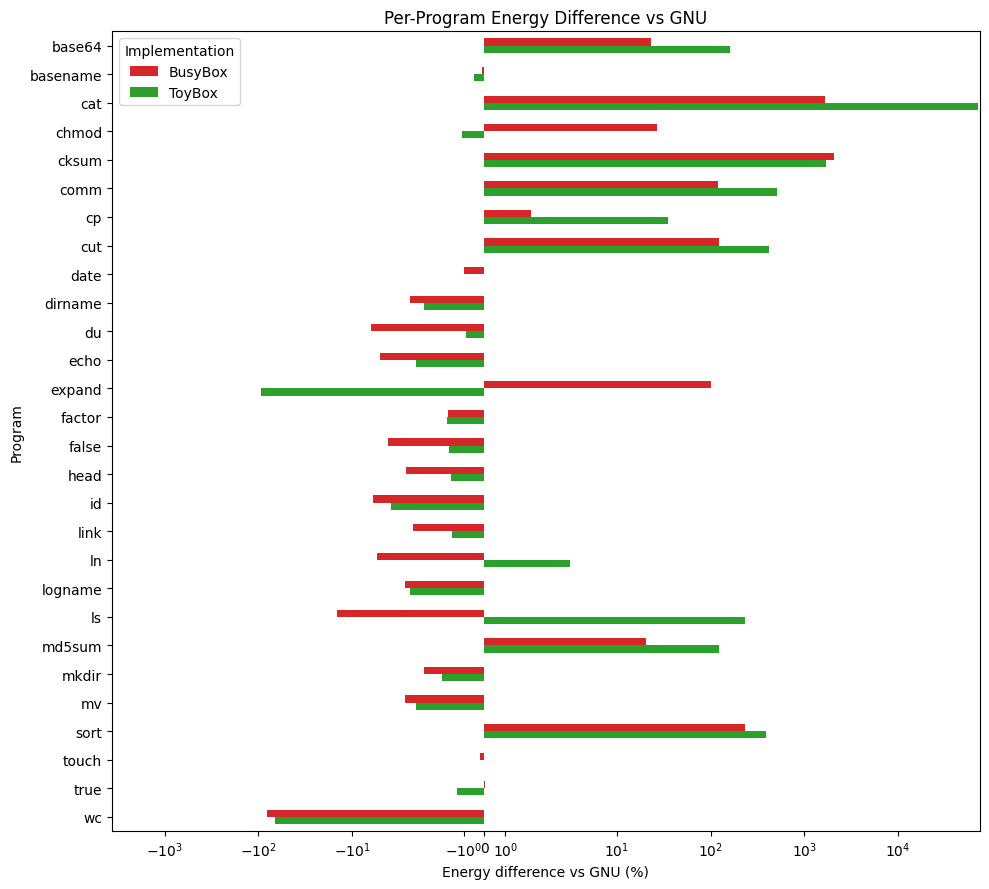

In [10]:
# Bar-plot of percent differences vs GNU (symlog scale)
import matplotlib.pyplot as plt

# new_df contains 'BusyBox' and 'ToyBox' diff percentages

fig, ax = plt.subplots(figsize=(10, 9))
new_df.plot(kind='barh', ax=ax, color=['#d62728', '#2ca02c'], legend=True)
# apply symmetric log scale with linear threshold around small values
ax.set_xscale('symlog', linthresh=5)
ax.set_xlabel('Energy difference vs GNU (%)')
ax.set_title('Per-Program Energy Difference vs GNU')
ax.legend(title='Implementation')
ax.invert_yaxis()  # keep program order top→bottom
plt.tight_layout()
plt.show()

In [11]:
# Summary statistics on per‐program energy consumption
# Count programs where ToyBox or BusyBox exceeds GNU
total = len(df_pivot)
toy_higher = (df_pivot['PSYS']['ToyBox'] > df_pivot['PSYS']['GNU']).sum()
bb_higher  = (df_pivot['PSYS']['BusyBox'] > df_pivot['PSYS']['GNU']).sum()
print(f"ToyBox > GNU: {toy_higher}/{total} programs ({toy_higher/total:.1%})")
print(f"BusyBox > GNU: {bb_higher}/{total} programs ({bb_higher/total:.1%})")

# Descriptive stats (microjoules) for each implementation
# Disable scientific notation and format count as integer
pd.options.display.float_format = '{:.0f}'.format
stats = df_pivot['PSYS'].describe()
print(stats)

ToyBox > GNU: 10/28 programs (35.7%)
BusyBox > GNU: 11/28 programs (39.3%)
Utilities   BusyBox       GNU     ToyBox
count            28        28         28
mean       39011444  30854240  111330620
std        80718862  89930548  301070527
min          293713    294027     290862
25%          305313    319335     311903
50%          314237    325196     325934
75%        20313366   3473735   45410864
max       318299265 454693407 1517433316


In [12]:
# Compute correlation between binary size (KiB) and energy consumption (J)

# Load binary sizes and convert to KiB
size_df = pd.read_csv(os.path.join(inputs_dir, 'programs30.csv'), delimiter=';')
size_df.set_index('Program', inplace=True)
sizes_kib = size_df[['GNU','BusyBox','ToyBox']] / 1024
sizes_kib = sizes_kib.rename(columns=lambda x: x + '_KiB')

# Extract energy (J) from df_pivot (which was in µJ)
energy_j = df_pivot['PSYS'] / 1e6
energy_j = energy_j.rename(columns=lambda x: x + '_J')

# Combine sizes and energy into one DataFrame
combined = sizes_kib.join(energy_j)

# Compute Spearman correlations
corr = combined.corr(method='spearman').round(2)
print('Correlation matrix between size [KiB] and energy [J]:')
print(corr)

# Specifically, how size of each implementation correlates with its own energy
for impl in ['GNU','BusyBox','ToyBox']:
    print(f"{impl} size vs energy: {corr.loc[f'{impl}_KiB', f'{impl}_J']:.2f}")

Correlation matrix between size [KiB] and energy [J]:
             GNU_KiB  BusyBox_KiB  ToyBox_KiB  BusyBox_J  GNU_J  ToyBox_J
GNU_KiB            1            1           1          0      0         0
BusyBox_KiB        1            1           1          0      0         0
ToyBox_KiB         1            1           1          0      0         0
BusyBox_J          0            0           0          1      1         1
GNU_J              0            0           0          1      1         1
ToyBox_J           0            0           0          1      1         1
GNU size vs energy: 0.25
BusyBox size vs energy: 0.30
ToyBox size vs energy: 0.35


In [13]:
# Correlation between # configuration options and energy consumption
opts_df = pd.read_csv(os.path.join(inputs_dir, 'programs_nr_options30.csv'), delimiter=';')
opts_df.set_index('Program', inplace=True)
opts = opts_df[['GNU', 'BusyBox', 'ToyBox']].rename(columns=lambda x: x + '_opts')

# Energy in joules
energy_j = df_pivot['PSYS'] / 1e6
energy_j = energy_j.rename(columns=lambda x: x + '_J')

# Combine options and energy
combined_opts = opts.join(energy_j)

# Compute Spearman correlations
corr_opts = combined_opts.corr(method='spearman').round(2)
print('Correlation matrix between #options and energy [J]:')
print(corr_opts)

# Per-implementation correlation
for impl in ['GNU', 'BusyBox', 'ToyBox']:
    print(f"{impl} opts vs energy: {corr_opts.loc[f'{impl}_opts', f'{impl}_J']:.2f}")

Correlation matrix between #options and energy [J]:
              GNU_opts  BusyBox_opts  ToyBox_opts  BusyBox_J  GNU_J  ToyBox_J
GNU_opts             1             1            1          0      0         1
BusyBox_opts         1             1            1          0      0         0
ToyBox_opts          1             1            1          0      0         0
BusyBox_J            0             0            0          1      1         1
GNU_J                0             0            0          1      1         1
ToyBox_J             1             0            0          1      1         1
GNU opts vs energy: 0.46
BusyBox opts vs energy: 0.27
ToyBox opts vs energy: 0.39


In [14]:
# Correlation between execution time (s) and energy consumption (J)
# load and pivot runtime data
dur_file = os.path.join(results_dir, 'averageDURATION_all_repeats.csv')
df_dur   = pd.read_csv(dur_file, delimiter=';')
time_df  = df_dur.pivot(index='Program', columns='Utilities', values='DURATION')
time_s   = time_df.rename(columns=lambda x: x + '_s')

# energy in joules
energy_j = df_pivot['PSYS'] / 1e6
energy_j = energy_j.rename(columns=lambda x: x + '_J')

# combine and compute Spearman correlations
combined_time = time_s.join(energy_j)
corr_time    = combined_time.corr(method='spearman').round(2)
print('Correlation matrix between runtime [s] and energy [J]:')
print(corr_time)

# per-implementation correlation
for impl in ['GNU', 'BusyBox', 'ToyBox']:
    print(f"{impl} time vs energy: {corr_time.loc[f'{impl}_s', f'{impl}_J']:.2f}")

Correlation matrix between runtime [s] and energy [J]:
Utilities  BusyBox_s  GNU_s  ToyBox_s  BusyBox_J  GNU_J  ToyBox_J
Utilities                                                        
BusyBox_s          1      1         1          1      1         1
GNU_s              1      1         1          1      1         1
ToyBox_s           1      1         1          1      1         1
BusyBox_J          1      1         1          1      1         1
GNU_J              1      1         1          1      1         1
ToyBox_J           1      1         1          1      1         1
GNU time vs energy: 0.89
BusyBox time vs energy: 0.96
ToyBox time vs energy: 0.97


**Note:** The `DURATION` field corresponds to the measured execution time (in seconds) for each program run.

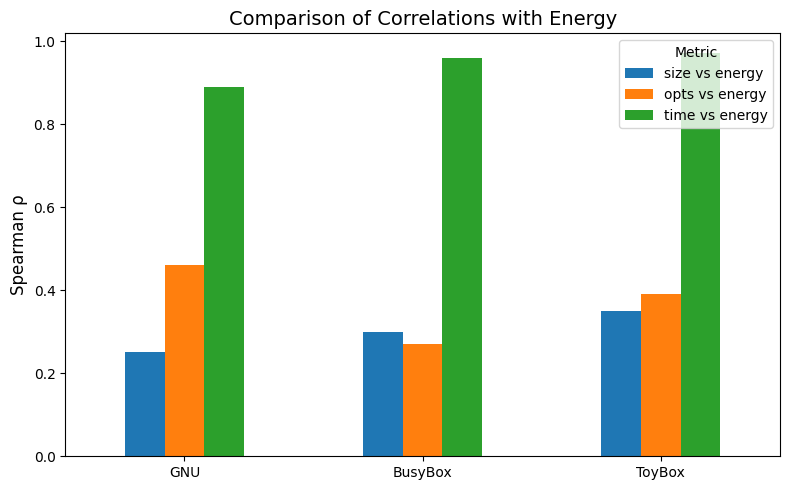

In [15]:
# Compare correlations in one plot
corr_summary = pd.DataFrame({
    'size vs energy': [
        corr.loc['GNU_KiB','GNU_J'],
        corr.loc['BusyBox_KiB','BusyBox_J'],
        corr.loc['ToyBox_KiB','ToyBox_J']
    ],
    'opts vs energy': [
        corr_opts.loc['GNU_opts','GNU_J'],
        corr_opts.loc['BusyBox_opts','BusyBox_J'],
        corr_opts.loc['ToyBox_opts','ToyBox_J']
    ],
    'time vs energy': [
        corr_time.loc['GNU_s','GNU_J'],
        corr_time.loc['BusyBox_s','BusyBox_J'],
        corr_time.loc['ToyBox_s','ToyBox_J']
    ]
}, index=['GNU','BusyBox','ToyBox'])

ax = corr_summary.plot.bar(figsize=(8,5))
ax.set_ylabel('Spearman ρ', fontsize=12)
ax.set_title('Comparison of Correlations with Energy', fontsize=14)
ax.legend(loc='upper right', title='Metric', fontsize=10)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [16]:
# Summary: execution time vs energy correlations
for impl in ['GNU', 'BusyBox', 'ToyBox']:
    rho = corr_time.loc[f'{impl}_s', f'{impl}_J']
    print(f"{impl} time vs energy: {rho:.2f}")

GNU time vs energy: 0.89
BusyBox time vs energy: 0.96
ToyBox time vs energy: 0.97


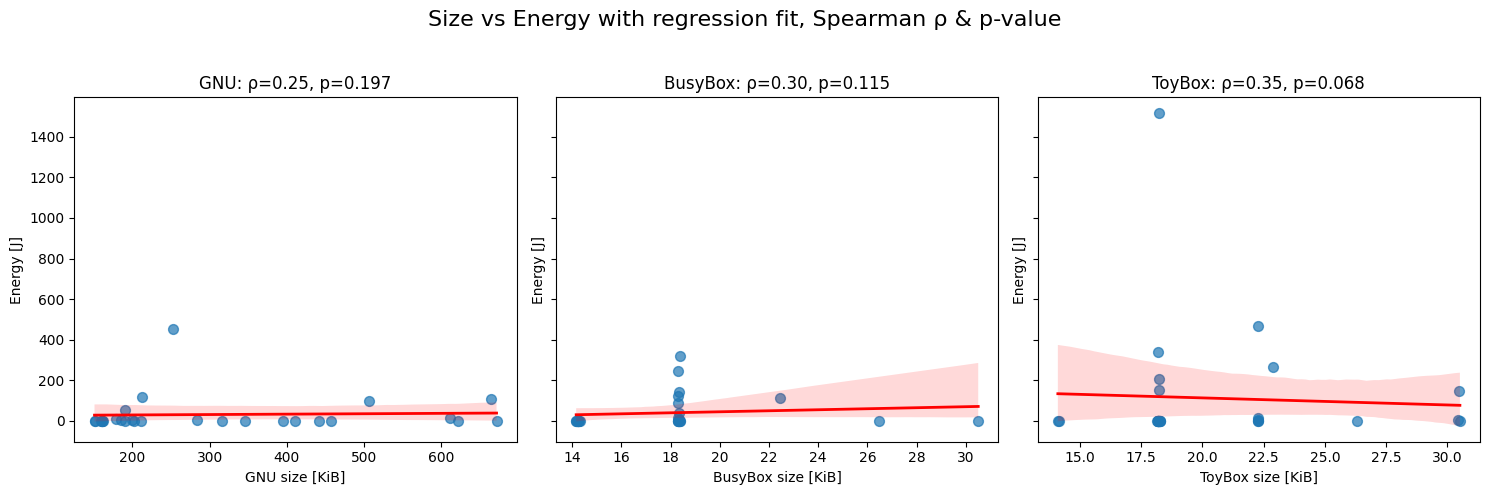

In [17]:
# Scatter + regression: size vs. energy per implementation
import seaborn as sns

impls = ['GNU','BusyBox','ToyBox']
fig, axes = plt.subplots(1, len(impls), figsize=(15,5), sharey=True)
for ax, impl in zip(axes, impls):
    # join and drop NaNs to match lengths
    tmp = pd.concat([sizes_kib[f'{impl}_KiB'], energy_j[f'{impl}_J']], axis=1).dropna()
    x = tmp[f'{impl}_KiB']
    y = tmp[f'{impl}_J']
    rho, pval = spearmanr(x, y)
    sns.regplot(x=x, y=y, ax=ax, fit_reg=True,
                scatter_kws={'s':50, 'alpha':0.7},
                line_kws={'color':'red','lw':2})
    ax.set_xlabel(f'{impl} size [KiB]')
    ax.set_ylabel('Energy [J]')
    ax.set_title(f'{impl}: ρ={rho:.2f}, p={pval:.3f}', fontsize=12)

plt.suptitle('Size vs Energy with regression fit, Spearman ρ & p-value', fontsize=16)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

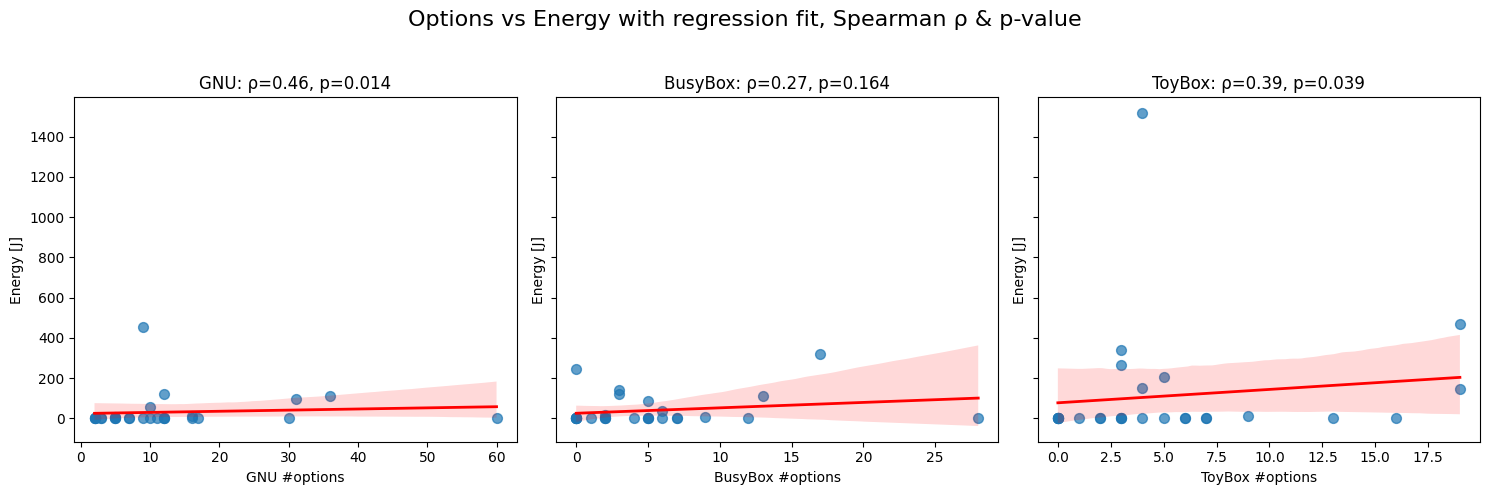

In [18]:
# Scatter + regression: options vs. energy per implementation
import seaborn as sns
impls = ['GNU','BusyBox','ToyBox']
fig, axes = plt.subplots(1, len(impls), figsize=(15,5), sharey=True)
for ax, impl in zip(axes, impls):
    tmp = pd.concat([opts[f'{impl}_opts'], energy_j[f'{impl}_J']], axis=1).dropna()
    x = tmp[f'{impl}_opts']
    y = tmp[f'{impl}_J']
    rho, pval = spearmanr(x, y)
    sns.regplot(x=x, y=y, ax=ax, fit_reg=True,
                scatter_kws={'s':50,'alpha':0.7},
                line_kws={'color':'red','lw':2})
    ax.set_xlabel(f'{impl} #options')
    ax.set_ylabel('Energy [J]')
    ax.set_title(f'{impl}: ρ={rho:.2f}, p={pval:.3f}', fontsize=12)
plt.suptitle('Options vs Energy with regression fit, Spearman ρ & p-value', fontsize=16)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

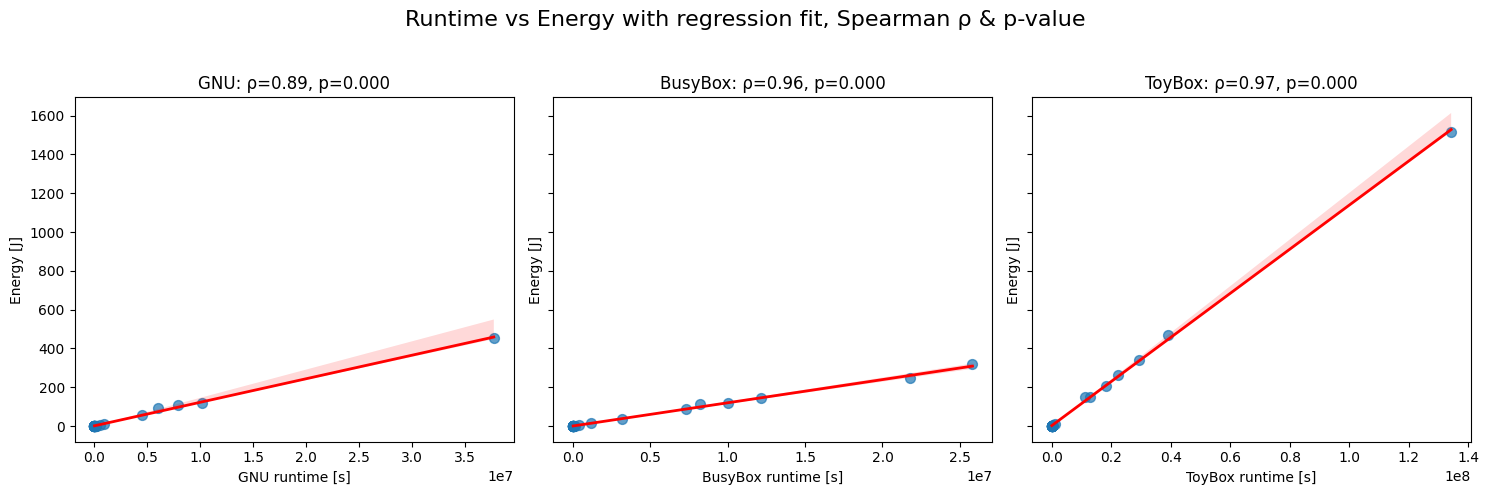

In [19]:
# Scatter + regression: time vs. energy per implementation
import seaborn as sns
impls = ['GNU','BusyBox','ToyBox']
fig, axes = plt.subplots(1, len(impls), figsize=(15,5), sharey=True)
for ax, impl in zip(axes, impls):
    tmp = pd.concat([time_s[f'{impl}_s'], energy_j[f'{impl}_J']], axis=1).dropna()
    x = tmp[f'{impl}_s']
    y = tmp[f'{impl}_J']
    rho, pval = spearmanr(x, y)
    sns.regplot(x=x, y=y, ax=ax, fit_reg=True,
                scatter_kws={'s':50,'alpha':0.7},
                line_kws={'color':'red','lw':2})
    ax.set_xlabel(f'{impl} runtime [s]')
    ax.set_ylabel('Energy [J]')
    ax.set_title(f'{impl}: ρ={rho:.2f}, p={pval:.3f}', fontsize=12)
plt.suptitle('Runtime vs Energy with regression fit, Spearman ρ & p-value', fontsize=16)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

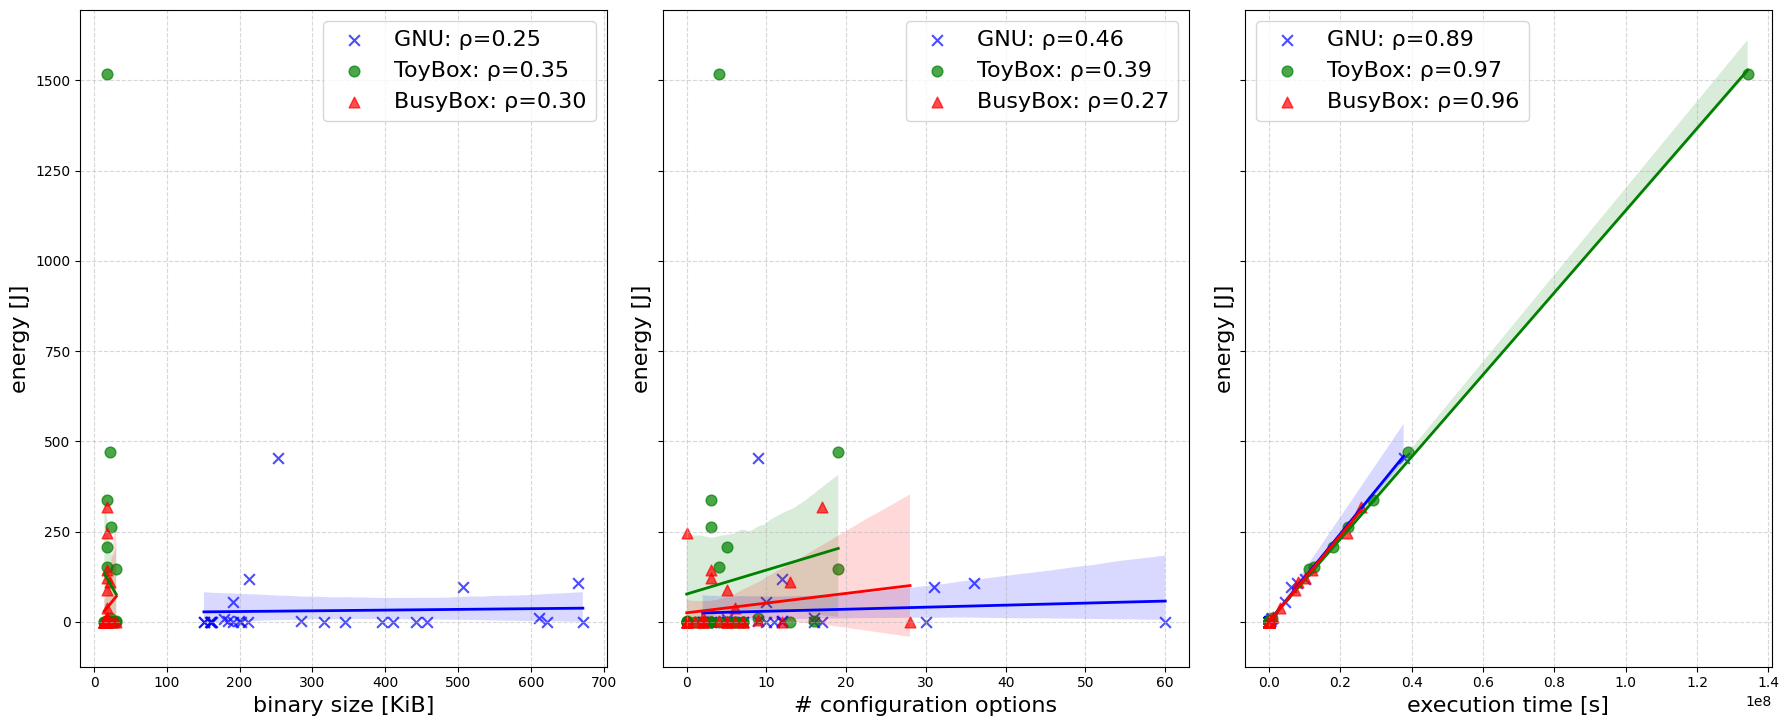

In [33]:
# Combined scatter: size, options, and time vs. energy
# change here...
import seaborn as sns
fig, axes = plt.subplots(1, 3, figsize=(18, 8), sharey=True)
params = [
    ('binary size [KiB]', sizes_kib, '_KiB'),
    ('# configuration options', opts, '_opts'),
    ('execution time [s]', time_s, '_s')
]
colors = {'GNU':'blue', 'ToyBox':'green', 'BusyBox':'red'}
markers = {'GNU':'x', 'ToyBox':'o', 'BusyBox':'^'}
for ax, (xlabel, df_param, suffix) in zip(axes, params):
    for impl in ['GNU','ToyBox','BusyBox']:
        tmp = pd.concat([df_param[f'{impl}{suffix}'], energy_j[f'{impl}_J']], axis=1).dropna()
        x = tmp[f'{impl}{suffix}']
        y = tmp[f'{impl}_J']
        rho, _ = spearmanr(x, y, nan_policy='omit')
        ax.scatter(x, y,
                   label=f"{impl}: ρ={rho:.2f}",
                   color=colors[impl],
                   marker=markers[impl], s=60, alpha=0.7)
        sns.regplot(x=x, y=y, ax=ax, scatter=False,
                    color=colors[impl], line_kws={'lw':2})
    ax.set_xlabel(xlabel, fontsize=16)
    ax.set_ylabel('energy [J]', fontsize=16)
    ax.legend(fontsize=16)
    ax.grid(True, linestyle='--', alpha=0.5)
# plt.suptitle('Metrics vs Energy (Scatter + Linear Fit)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()
# change here: replace per‐panel legend with overall legend showing ρ values
from matplotlib.lines import Line2D
handles = [ Line2D([], [], color=colors[impl], marker=markers[impl], linestyle='')
             for impl in ['GNU','ToyBox','BusyBox'] ]
labels = []
for impl in ['GNU','ToyBox','BusyBox']:
    sr = corr.loc[f'{impl}_KiB', f'{impl}_J']
    or_ = corr_opts.loc[f'{impl}_opts', f'{impl}_J']
    tr = corr_time.loc[f'{impl}_s', f'{impl}_J']
    labels.append(f"{impl}: size ρ={sr:.2f}, opts ρ={or_:.2f}, time ρ={tr:.2f}")
axes[-1].legend(handles, labels, loc='upper right', fontsize=20)

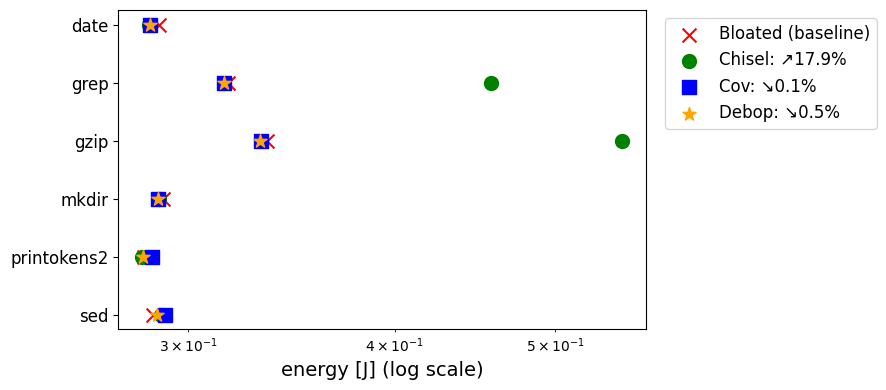

In [58]:
# Dot-plot per-program energy for bloated vs debloated variants
import pandas as pd, matplotlib.pyplot as plt

# load and average PSYS energy (µJ) per Program & Utilities
df = pd.read_csv(
    '/home/ternava/Documents/GitHub/bloat-energy-consumption/notebooks/debloating_results/cat_all_repeats.csv',
    delimiter=';'
)
psys_avg = df.groupby(['Program','Utilities'])['PSYS'].mean().unstack()

# convert to joules
psys_j = psys_avg / 1e6

# prepare data
prog = psys_j.index
baseline = psys_j['bloated']
variants = ['chisel','cov','debop']
markers = {'chisel':'o','cov':'s','debop':'*'}
colors = {'chisel':'green','cov':'blue','debop':'orange'}

# compute mean % reduction vs baseline
pct = (baseline.values[:,None] - psys_j[variants].values) / baseline.values[:,None] * 100
mean_pct = dict(zip(variants, pct.mean(axis=0)))

# plot
fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(baseline, prog, marker='x', color='red',   s=100, label='Bloated (baseline)')
for v in variants:
    arr   = psys_j[v]
    mpct  = mean_pct[v]
    arrow = '↘' if mpct>0 else '↗'
    lbl   = f"{v.capitalize()}: {arrow}{abs(mpct):.1f}%"
    ax.scatter(arr, prog, marker=markers[v], color=colors[v], s=100, label=lbl)

ax.set_xscale('log')
ax.set_xlabel('energy [J] (log scale)', fontsize=14)
#ax.set_ylabel('Program')
ax.invert_yaxis()
ax.tick_params(axis='y', labelsize=12)
ax.legend(fontsize=12, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

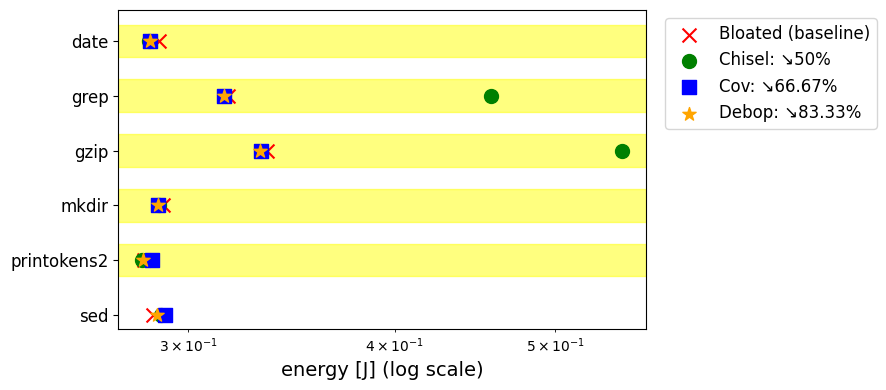

In [59]:
# Dot-plot per-program energy for bloated vs debloated variants (with highlights)
import pandas as pd, matplotlib.pyplot as plt

# load & average PSYS energy (µJ) per Program & Utilities
df = pd.read_csv(
    '/home/ternava/Documents/GitHub/bloat-energy-consumption/notebooks/debloating_results/cat_all_repeats.csv',
    delimiter=';'
)
psys_avg = df.groupby(['Program','Utilities'])['PSYS'].mean().unstack()
psys_j   = psys_avg / 1e6

# prepare data
prog      = psys_j.index
baseline  = psys_j['bloated']
variants  = ['chisel','cov','debop']
markers   = {'chisel':'o','cov':'s','debop':'*'}
colors    = {'chisel':'green','cov':'blue','debop':'orange'}
pct       = (baseline.values[:,None] - psys_j[variants].values) / baseline.values[:,None] * 100
mean_pct  = dict(zip(variants, pct.mean(axis=0)))

# plot points
fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(baseline, prog, marker='x', color='red', s=100, label='Bloated (baseline)')
ax.scatter(psys_j['chisel'], prog, marker=markers['chisel'], color=colors['chisel'], s=100, label='Chisel: ↘50%')
ax.scatter(psys_j['cov'],     prog, marker=markers['cov'],     color=colors['cov'],     s=100, label='Cov: ↘66.67%')
ax.scatter(psys_j['debop'],   prog, marker=markers['debop'],   color=colors['debop'],   s=100, label='Debop: ↘83.33%')

# highlight all programs except 'sed' in light yellow 

for name in prog:
    if name != 'sed':
        y = prog.tolist().index(name)
        ax.axhspan(y-0.3, y+0.3, color='yellow', alpha=0.5, zorder=0)

# final plot adjustments...
ax.set_xscale('log')
ax.set_xlabel('energy [J] (log scale)', fontsize=14)
ax.invert_yaxis()
ax.tick_params(axis='y', labelsize=12)
ax.legend(fontsize=12, bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()

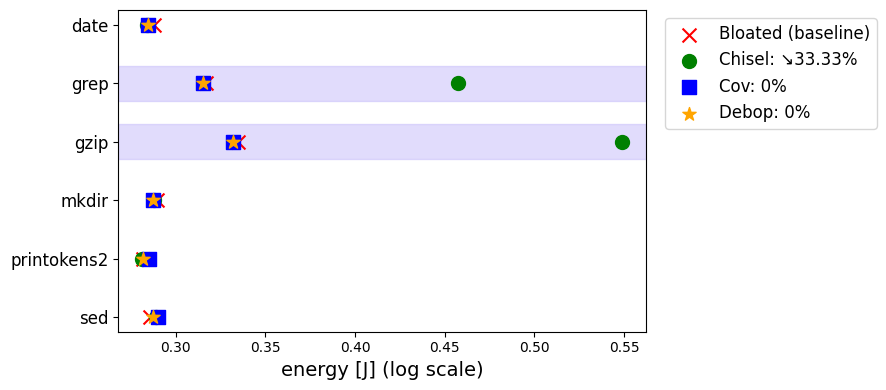

In [62]:
# Dot-plot per-program energy for bloated vs debloated variants (with highlights)
import pandas as pd, matplotlib.pyplot as plt

# load & average PSYS energy (µJ) per Program & Utilities
df = pd.read_csv(
    '/home/ternava/Documents/GitHub/bloat-energy-consumption/notebooks/debloating_results/cat_all_repeats.csv',
    delimiter=';'
)
psys_avg = df.groupby(['Program','Utilities'])['PSYS'].mean().unstack()
psys_j   = psys_avg / 1e6

# prepare data
prog      = psys_j.index
baseline  = psys_j['bloated']
variants  = ['chisel','cov','debop']
markers   = {'chisel':'o','cov':'s','debop':'*'}
colors    = {'chisel':'green','cov':'blue','debop':'orange'}
pct       = (baseline.values[:,None] - psys_j[variants].values) / baseline.values[:,None] * 100
mean_pct  = dict(zip(variants, pct.mean(axis=0)))

# plot points
fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(baseline, prog, marker='x', color='red', s=100, label='Bloated (baseline)')
ax.scatter(psys_j['chisel'], prog, marker=markers['chisel'], color=colors['chisel'], s=100, label='Chisel: ↘33.33%')
ax.scatter(psys_j['cov'],     prog, marker=markers['cov'],     color=colors['cov'],     s=100, label='Cov: 0%')
ax.scatter(psys_j['debop'],   prog, marker=markers['debop'],   color=colors['debop'],   s=100, label='Debop: 0%')

# highlight grep and gzip in light green (narrower)
for name in ['grep','gzip']:
    y = prog.tolist().index(name)
    ax.axhspan(y-0.3, y+0.3, color='#C4BAFA', alpha=0.5, zorder=0)

ax.set_xlabel('energy [J] (log scale)', fontsize=14)
#ax.set_ylabel('Program')
ax.invert_yaxis()
ax.tick_params(axis='y', labelsize=12)
ax.legend(fontsize=12, bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()

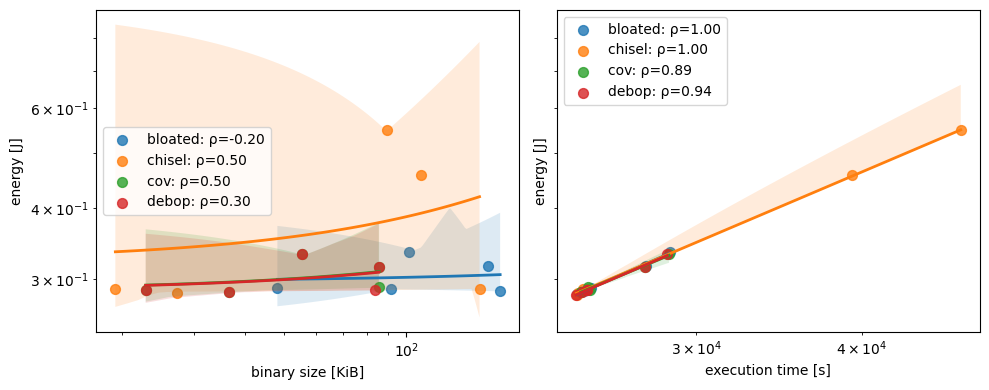

In [50]:
# Correlation: size & time vs energy for bloated/debloated variants
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import spearmanr

# load binary sizes (KiB)
size_df = pd.read_csv(os.path.join(current_dir,'debloating_results/all_ec_bsize.csv'), delimiter=';')
size_df = size_df.pivot(index='Program', columns='Utilities', values='Size') / 1024

# load execution times (s)
dur_df  = pd.read_csv(os.path.join(current_dir,'debloating_results/averageDURATION_all_repeats.csv'), delimiter=';')
dur_df  = dur_df.pivot(index='Program', columns='Utilities', values='DURATION')

# load energy (J)
df_cat  = pd.read_csv(os.path.join(current_dir,'debloating_results/cat_all_repeats.csv'), delimiter=';')
psys_df = df_cat.groupby(['Program','Utilities'])['PSYS'].mean().unstack() / 1e6

impls = ['bloated','chisel','cov','debop']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# size vs energy
for impl in impls:
    x = size_df[impl].dropna()
    y = psys_df[impl].reindex(x.index)
    rho, _ = spearmanr(x, y, nan_policy='omit')
    sns.regplot(x=x, y=y, ax=ax1, scatter_kws={'s':50}, line_kws={'lw':2}, label=f'{impl}: ρ={rho:.2f}')
ax1.set_xscale('log'); ax1.set_yscale('log')
ax1.set_xlabel('binary size [KiB]'); ax1.set_ylabel('energy [J]')
ax1.legend()

# time vs energy
for impl in impls:
    x = dur_df[impl].dropna()
    y = psys_df[impl].reindex(x.index)
    rho, _ = spearmanr(x, y, nan_policy='omit')
    sns.regplot(x=x, y=y, ax=ax2, scatter_kws={'s':50}, line_kws={'lw':2}, label=f'{impl}: ρ={rho:.2f}')
ax2.set_xscale('log'); ax2.set_yscale('log')
ax2.set_xlabel('execution time [s]'); ax2.set_ylabel('energy [J]')
ax2.legend()

plt.tight_layout(); plt.show()

# Energy Consumption Viewer (ECV)

Energy Consumption Viewer is a tool to visualize results of the paper "".

- ECV uses progress bars to represent energy consumption per Linux command
- Provides time-equivalent for HDD, GPU, and LED bulb usage
- **Detailed mode:** access full energy & time-of-use data per measured configuration
- **Usage scenarios:**
  - **Developers:** measure and monitor energy while evolving utilities
  - **End-users:** compare energy costs in familiar device time units

With ECV, understanding and comparing configuration energy consumption becomes straightforward.

In [36]:
# Feature reduction examples for 'mkdir'
data = {
    'Implementation': ['GNU','ToyBox','BusyBox','Chisel (2 opts)','Chisel (3 opts)'],
    'Approach':       ['Original','Built-in','Built-in','On-demand','On-demand'],
    'Binary Size [KiB]': [420.6, 18.6, 18.7, 22.9, 16.5],
    '# Options':      [7, 3, 2, 2, 3]
}
df_examples = pd.DataFrame(data).set_index('Implementation')
df_examples

,Approach,Binary Size [KiB],# Options
Implementation,,,
GNU,Original,421,7
ToyBox,Built-in,19,3
BusyBox,Built-in,19,2
Chisel (2 opts),On-demand,23,2
Chisel (3 opts),On-demand,16,3


In [37]:
# Examples: built-in vs on-demand feature reduction for 'mkdir'
import pandas as pd

# Built-in reduction: ToyBox & BusyBox reimplement GNU
df_builtin = pd.DataFrame({
    'Implementation': ['ToyBox', 'BusyBox'],
    'Size_KiB': [18.6, 18.7],
    'Options': [3, 2]
}).set_index('Implementation')

# On-demand reduction: Chisel variants of GNU
df_ondemand = pd.DataFrame({
    'Implementation': ['Chisel (2 opts)', 'Chisel (3 opts)'],
    'Size_KiB': [22.9, 16.5],
    'Options': [2, 3]
}).set_index('Implementation')

print("Built-in reduction variants:")
display(df_builtin)
print("\nOn-demand reduction variants:")
display(df_ondemand)

Built-in reduction variants:


,Size_KiB,Options
Implementation,,
ToyBox,19,3
BusyBox,19,2



On-demand reduction variants:


,Size_KiB,Options
Implementation,,
Chisel (2 opts),23,2
Chisel (3 opts),16,3


**Legend explanation:**

- **Bloated (baseline)**: energy consumption (J) of the original bloated variant for each program.
- Each debloated variant label (e.g., `Chisel: ↘12.3%`) shows the mean % change relative to the bloated baseline.
- Arrows: ↘ indicates a reduction, ↗ an increase.
- % is computed as `(baseline – variant) / baseline × 100`.

In [ ]:
# Binary size of 'mkdir' in on-demand variants (KiB)
df_size = pd.read_csv(os.path.join(current_dir,'debloating_results/all_ec_bsize.csv'), delimiter=';')
size_df = df_size.pivot(index='Program', columns='Utilities', values='Size') / 1024
mkdir_sizes = size_df.loc['mkdir', ['chisel','cov','debop']]
print('mkdir sizes [KiB]:')
print(mkdir_sizes)